## Imports

In [1]:
import numpy as np
from itertools import product
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from joblib import Parallel, delayed
import multiprocessing
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt
import matplotlib
params = {'axes.titlesize':'15',
          'xtick.labelsize':'15',
          'ytick.labelsize':'15',
          'font.size':'16',
          'legend.fontsize':'medium',
          'lines.linewidth':'2.0',
          'font.weight':'normal',
          'lines.markersize':'5',
          'text.latex.preamble': r'\usepackage{amsfonts}',
          }
matplotlib.rcParams.update(params)
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# Local Imports
from krr import grr_client_vec
from estimators import MLE, INV_P, INV_N
from utils import log_likelihood, generate_synthetic_data
import cfg

## Parameters for the experiments

In [2]:
algorithms = {
            "MLE*": MLE, # Our MLE estimator
            "InvP": INV_P, # INV with projection into the simplex
            "InvN": INV_N, # INV with normalization
            }

metrics = {
            "neg_log_likelihood": None,
            "MSE": lambda truth, est: mean_squared_error(truth, est),
            }

color_map = {
            "MLE*": "blue",
            "InvP": "orange",
            "InvN": "green",
        }

marker_map = {
            "MLE*": "s",
            "InvP": "o",
            "InvN": "d",
        }

n_repeats = cfg.n_repeats # number of seeds to repeat each experiment

## Function to run experiments in parallel

In [3]:
def run_experiment(data, i, j, alg, met):
    eps, N, K, s = pops[i]
    rng = np.random.default_rng(j)

    if data is None:
        # Generate true data and histogram
        true_resp = generate_synthetic_data(N, K, s, seed=j)
    
    else:
        # Generate true data and histogram
        true_resp = data[s]#.sample(n=N, random_state=j, replace=True).values
        true_resp = pd.cut(true_resp, bins=K, labels=False, include_lowest=True)
        N = len(true_resp)
    
    true_counts = np.bincount(true_resp, minlength=K)
    true_hist = true_counts / N

    # Perturb with GRR
    p_truth = np.exp(eps) / (np.exp(eps) + K - 1)
    rand_resp = grr_client_vec(true_resp, K, p_truth, rng=rng)
    phi = np.bincount(rand_resp, minlength=K) / N

    # Estimate
    f_alg = algorithms[alg]
    theta = f_alg(phi, p_truth)
    assert np.isclose(np.sum(theta), 1), (theta, alg, i, j)

    # Metric
    f_met = metrics[met]
    if f_met is None:
        metric_value = -log_likelihood(phi, theta, p_truth)
    else:
        metric_value = f_met(theta, true_hist)

    return {
            "population": i,
            "eps": eps,
            "N": N,
            "K": K,
            "s": s,
            "algorithm": alg,
            "metric": met,
            "value": metric_value,
        }, (s, K, true_hist)  

## Run Experiments (Synthetic data)

In [4]:
pop_eps = cfg.pop_eps # Epsilon values to vary
pop_N = cfg.pop_N # Population sizes to vary
pop_K = cfg.pop_K # Domain sizes to vary
pop_s = cfg.pop_s # Concentration parameters (Zipf exponents) to vary

# Each combination is (eps, N, K, s)
pops = list(product(pop_eps, pop_N, pop_K, pop_s))
combinations = list(product(range(len(pops)), range(n_repeats), algorithms, metrics))
dic_true_hist = {s:{K:None for K in pop_K} for s in pop_s}

# Run in parallel
num_cores = multiprocessing.cpu_count()
results = Parallel(n_jobs=num_cores)(
    delayed(run_experiment)(None, i, j, alg, met)
    for i, j, alg, met in tqdm(combinations)
)

# Unpack results
out = []
dic_true_hist = {s: {K: None for K in pop_K} for s in pop_s}

for res, (s, K, true_hist) in results:
    out.append(res)
    dic_true_hist[s][K] = true_hist   # Overwrite or store the final version

100%|██████████| 45000/45000 [02:55<00:00, 256.64it/s] 


## Plotting

### Overview of results: fixed_eps

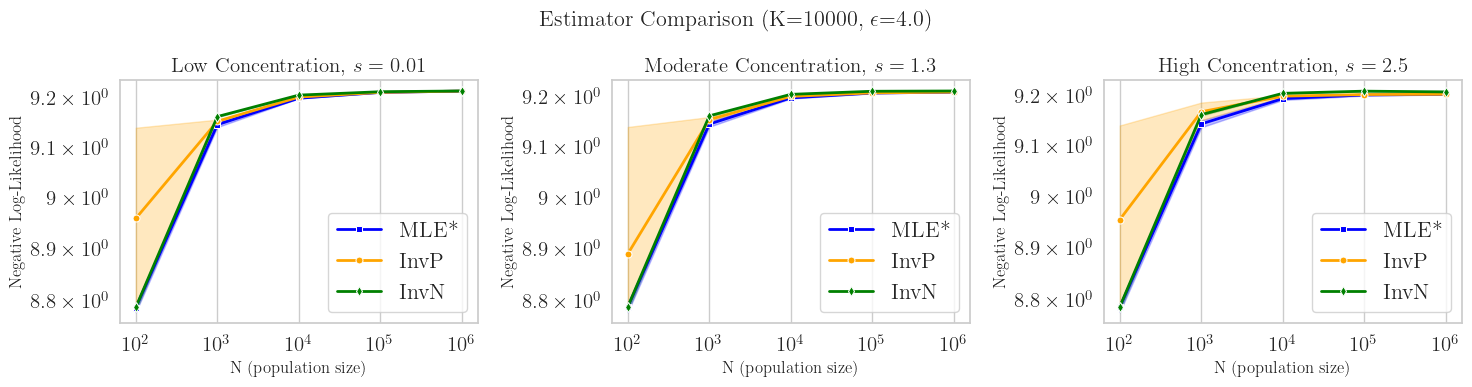

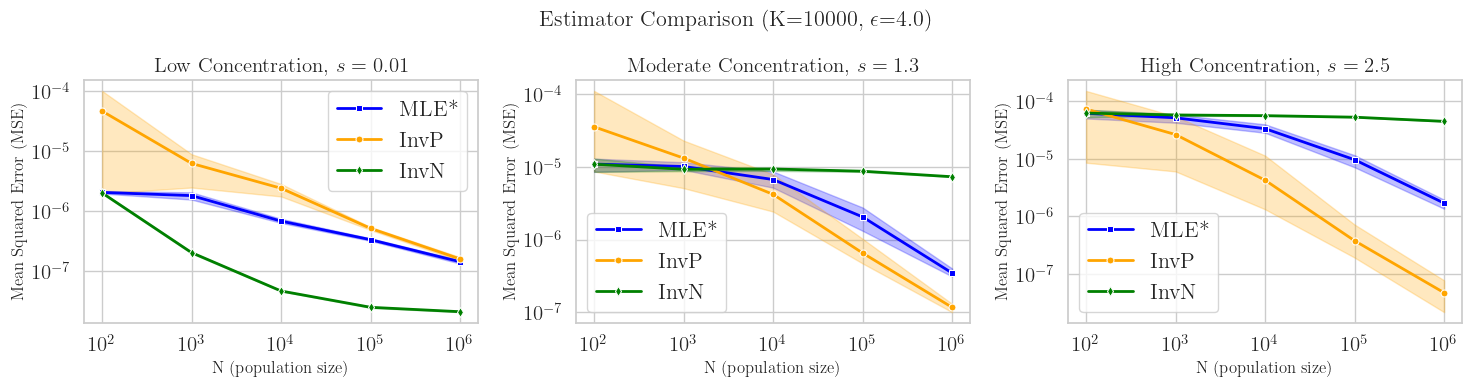

In [5]:
# Set fixed parameters
K_fixed = 10000
eps_fixed = 4.0
s_list = [0.01, 1.3, 2.5]  # uniform, moderate, spike

for met in metrics:

    # Create a figure with one row and three columns (one subplot per s)
    fig, axes = plt.subplots(
        1, len(s_list),
        figsize=(15, 4.5),
    )

    # get results into a DataFrame
    df_all = pd.DataFrame(out)

    for col_idx, s in enumerate(s_list):
        ax = axes[col_idx]
        plt.sca(ax)

        df = df_all.query(
            "metric == @met and eps == @eps_fixed and K == @K_fixed and s == @s"
        )

        if df.empty:
            ax.set_title(f"No data: eps={eps_fixed}, K={K_fixed}, s={s}")
            continue

        for alg in df.algorithm.unique():
            
            c = color_map.get(alg)
            mkr = marker_map.get(alg)

            df_line = df.query("algorithm == @alg").copy()
            sns.lineplot(
                data=df_line,
                x="N",
                y="value",
                color=c,
                estimator="mean",
                errorbar=("pi", 95),
                err_kws={"alpha": 0.25},
                marker=mkr,
                label=alg,
                lw=2,
            )

        if s <=0.25:
            ax.set_title(f"Low Concentration, $s = {s}$")
        elif 0.8 <= s <= 1.3:
            ax.set_title(f"Moderate Concentration, $s = {s}$")
        else:
            ax.set_title(f"High Concentration, $s = {s}$")
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_ylabel("Mean Squared Error (MSE)" if met == 'MSE' else "Negative Log-Likelihood")
        ax.set_xlabel("N (population size)")
        if col_idx == len(s_list) - 1:
            ax.legend()

    plt.suptitle(f"Estimator Comparison (K={K_fixed}, $\epsilon$={eps_fixed})", fontsize=16, y=0.9)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"results/overview_met_{met}_K{K_fixed}_eps{eps_fixed}.pdf", dpi=500, bbox_inches='tight')
    plt.show()


### Overview of results: fixed_n

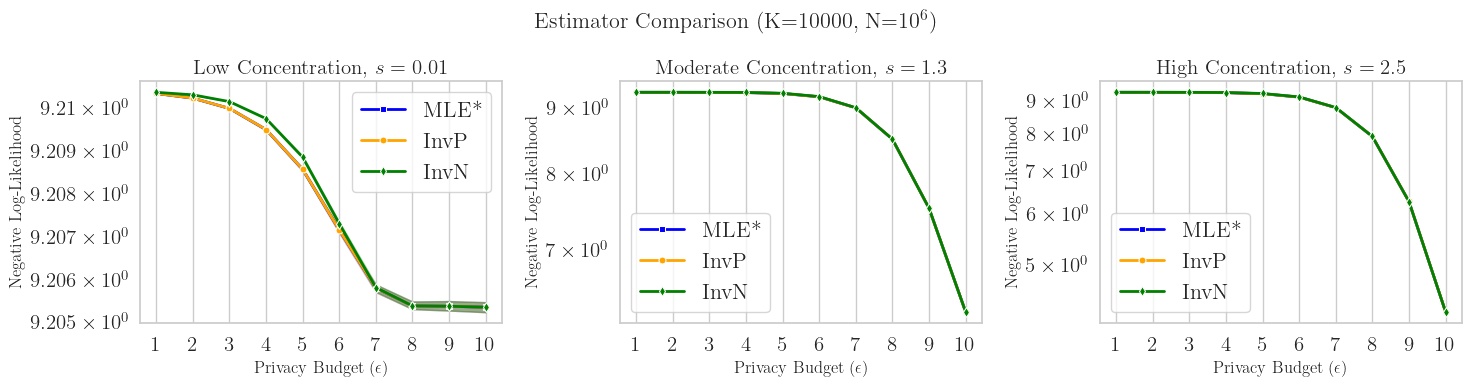

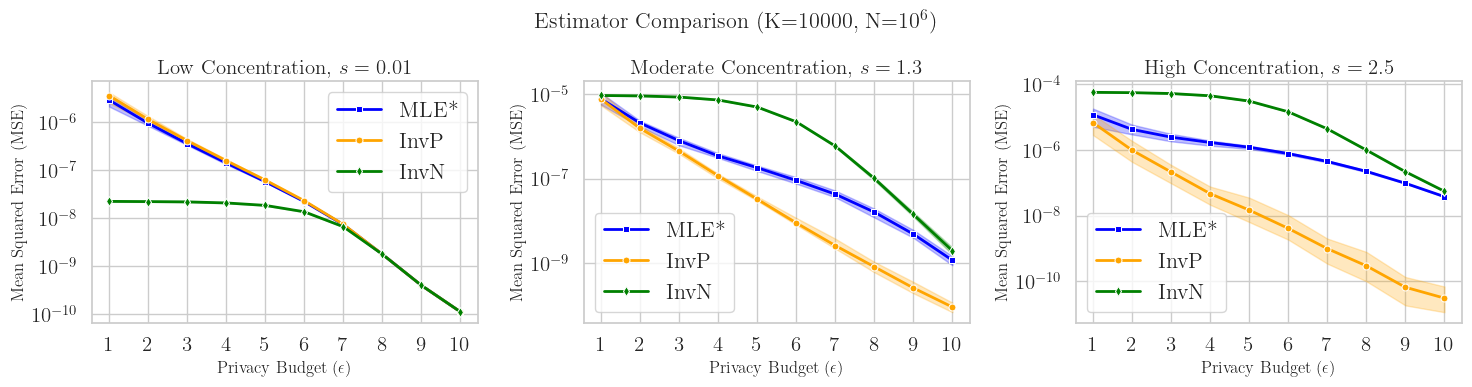

In [6]:
# Set fixed parameters
N_fixed = 10**6

for met in metrics:

    # Create a figure with one row and three columns (one subplot per s)
    fig, axes = plt.subplots(
        1, len(s_list),
        figsize=(15, 4.5),
    )

    # get results into a DataFrame
    df_all = pd.DataFrame(out)

    for col_idx, s in enumerate(s_list):
        ax = axes[col_idx]
        plt.sca(ax)

        df = df_all.query(
            "metric == @met and N == @N_fixed and K == @K_fixed and s == @s"
        )

        if df.empty:
            ax.set_title(f"No data: N={N_fixed}, K={K_fixed}, s={s}")
            continue

        for alg in df.algorithm.unique():
            c = color_map.get(alg)
            mkr = marker_map.get(alg)

            df_line = df.query("algorithm == @alg").copy()
            sns.lineplot(
                data=df_line,
                x="eps",
                y="value",
                color=c,
                estimator="mean",
                errorbar=("pi", 95),
                err_kws={"alpha": 0.25},
                marker=mkr,
                label=alg,
                lw=2,
            )

        if s <= 0.25:
            ax.set_title(f"Low Concentration, $s = {s}$")
        elif 0.8 <= s <= 1.3:
            ax.set_title(f"Moderate Concentration, $s = {s}$")
        else:
            ax.set_title(f"High Concentration, $s = {s}$")

        ax.set_yscale("log")
        ax.set_xticks(sorted(df["eps"].unique()))
        ax.set_xlabel("Privacy Budget ($\epsilon$)")
        ax.set_ylabel("Mean Squared Error (MSE)" if met == 'MSE' else "Negative Log-Likelihood")
        if col_idx == len(s_list) - 1:
            ax.legend()

    plt.suptitle(f"Estimator Comparison (K={K_fixed}, N=$10^6$)", fontsize=16, y=0.9)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"results/overview_met_{met}_K{K_fixed}_N{N_fixed}.pdf", dpi=500, bbox_inches='tight')
    plt.show()


### All results

Metric: neg_log_likelihood


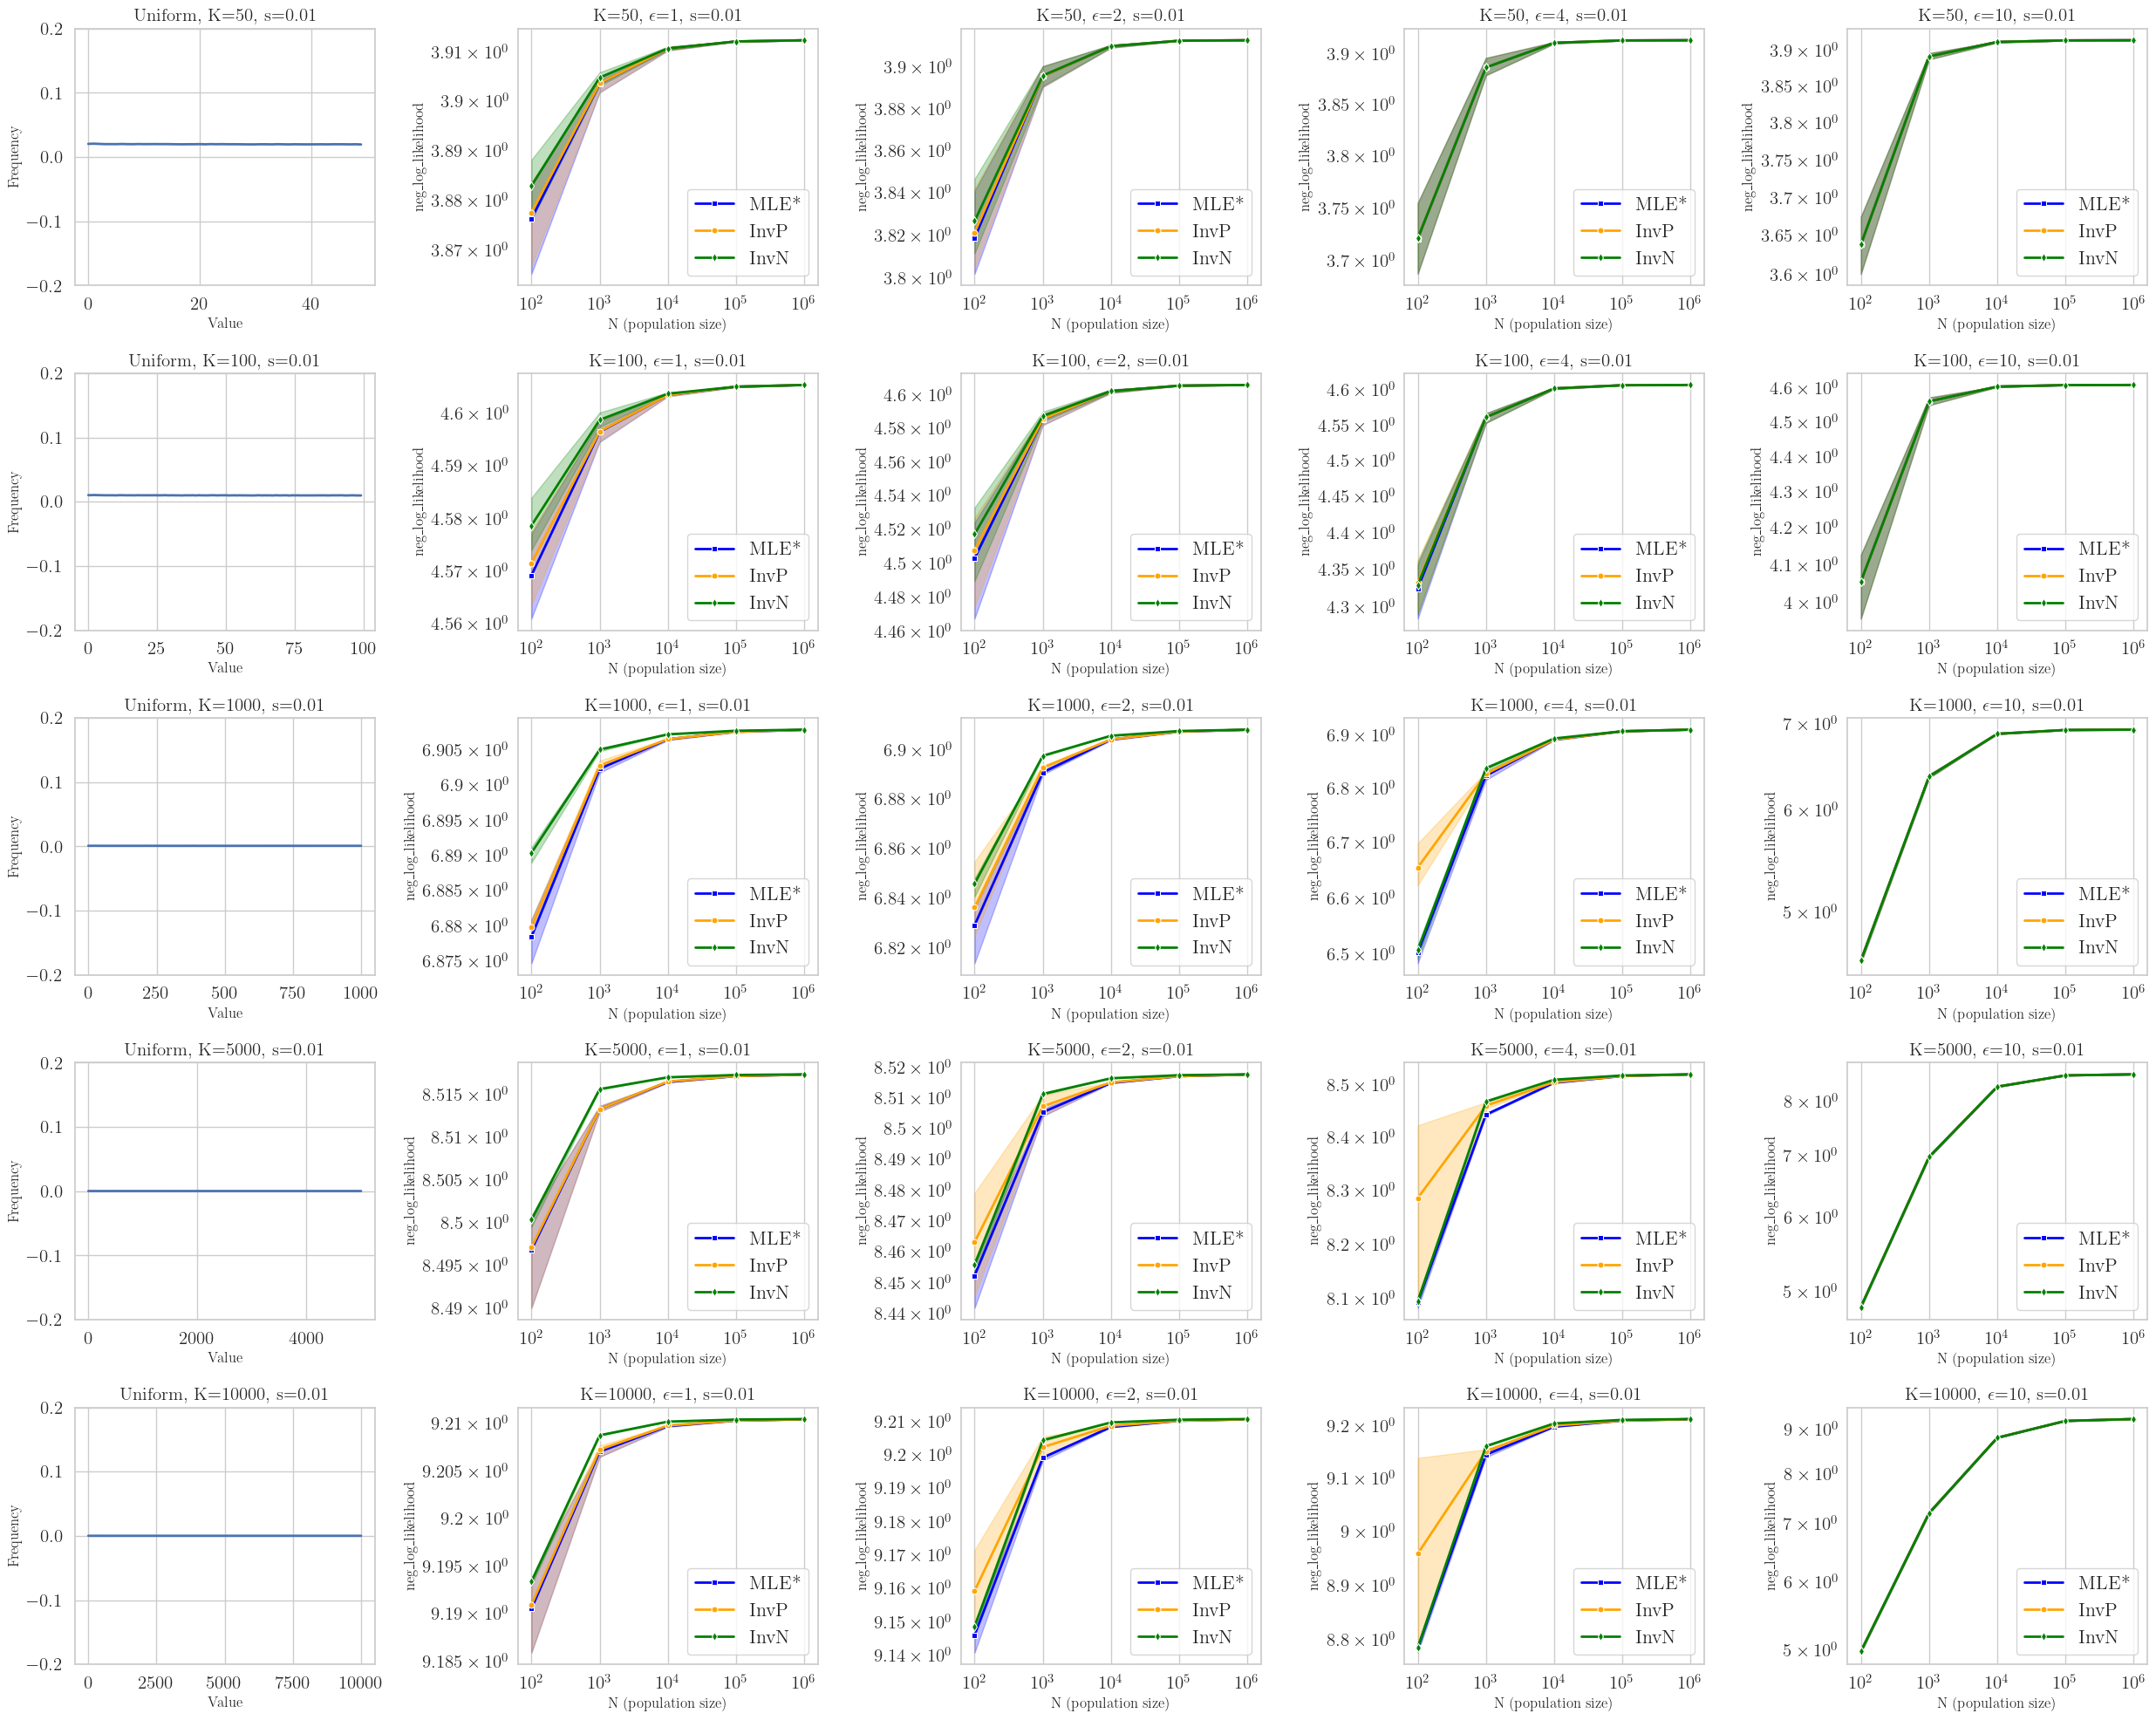

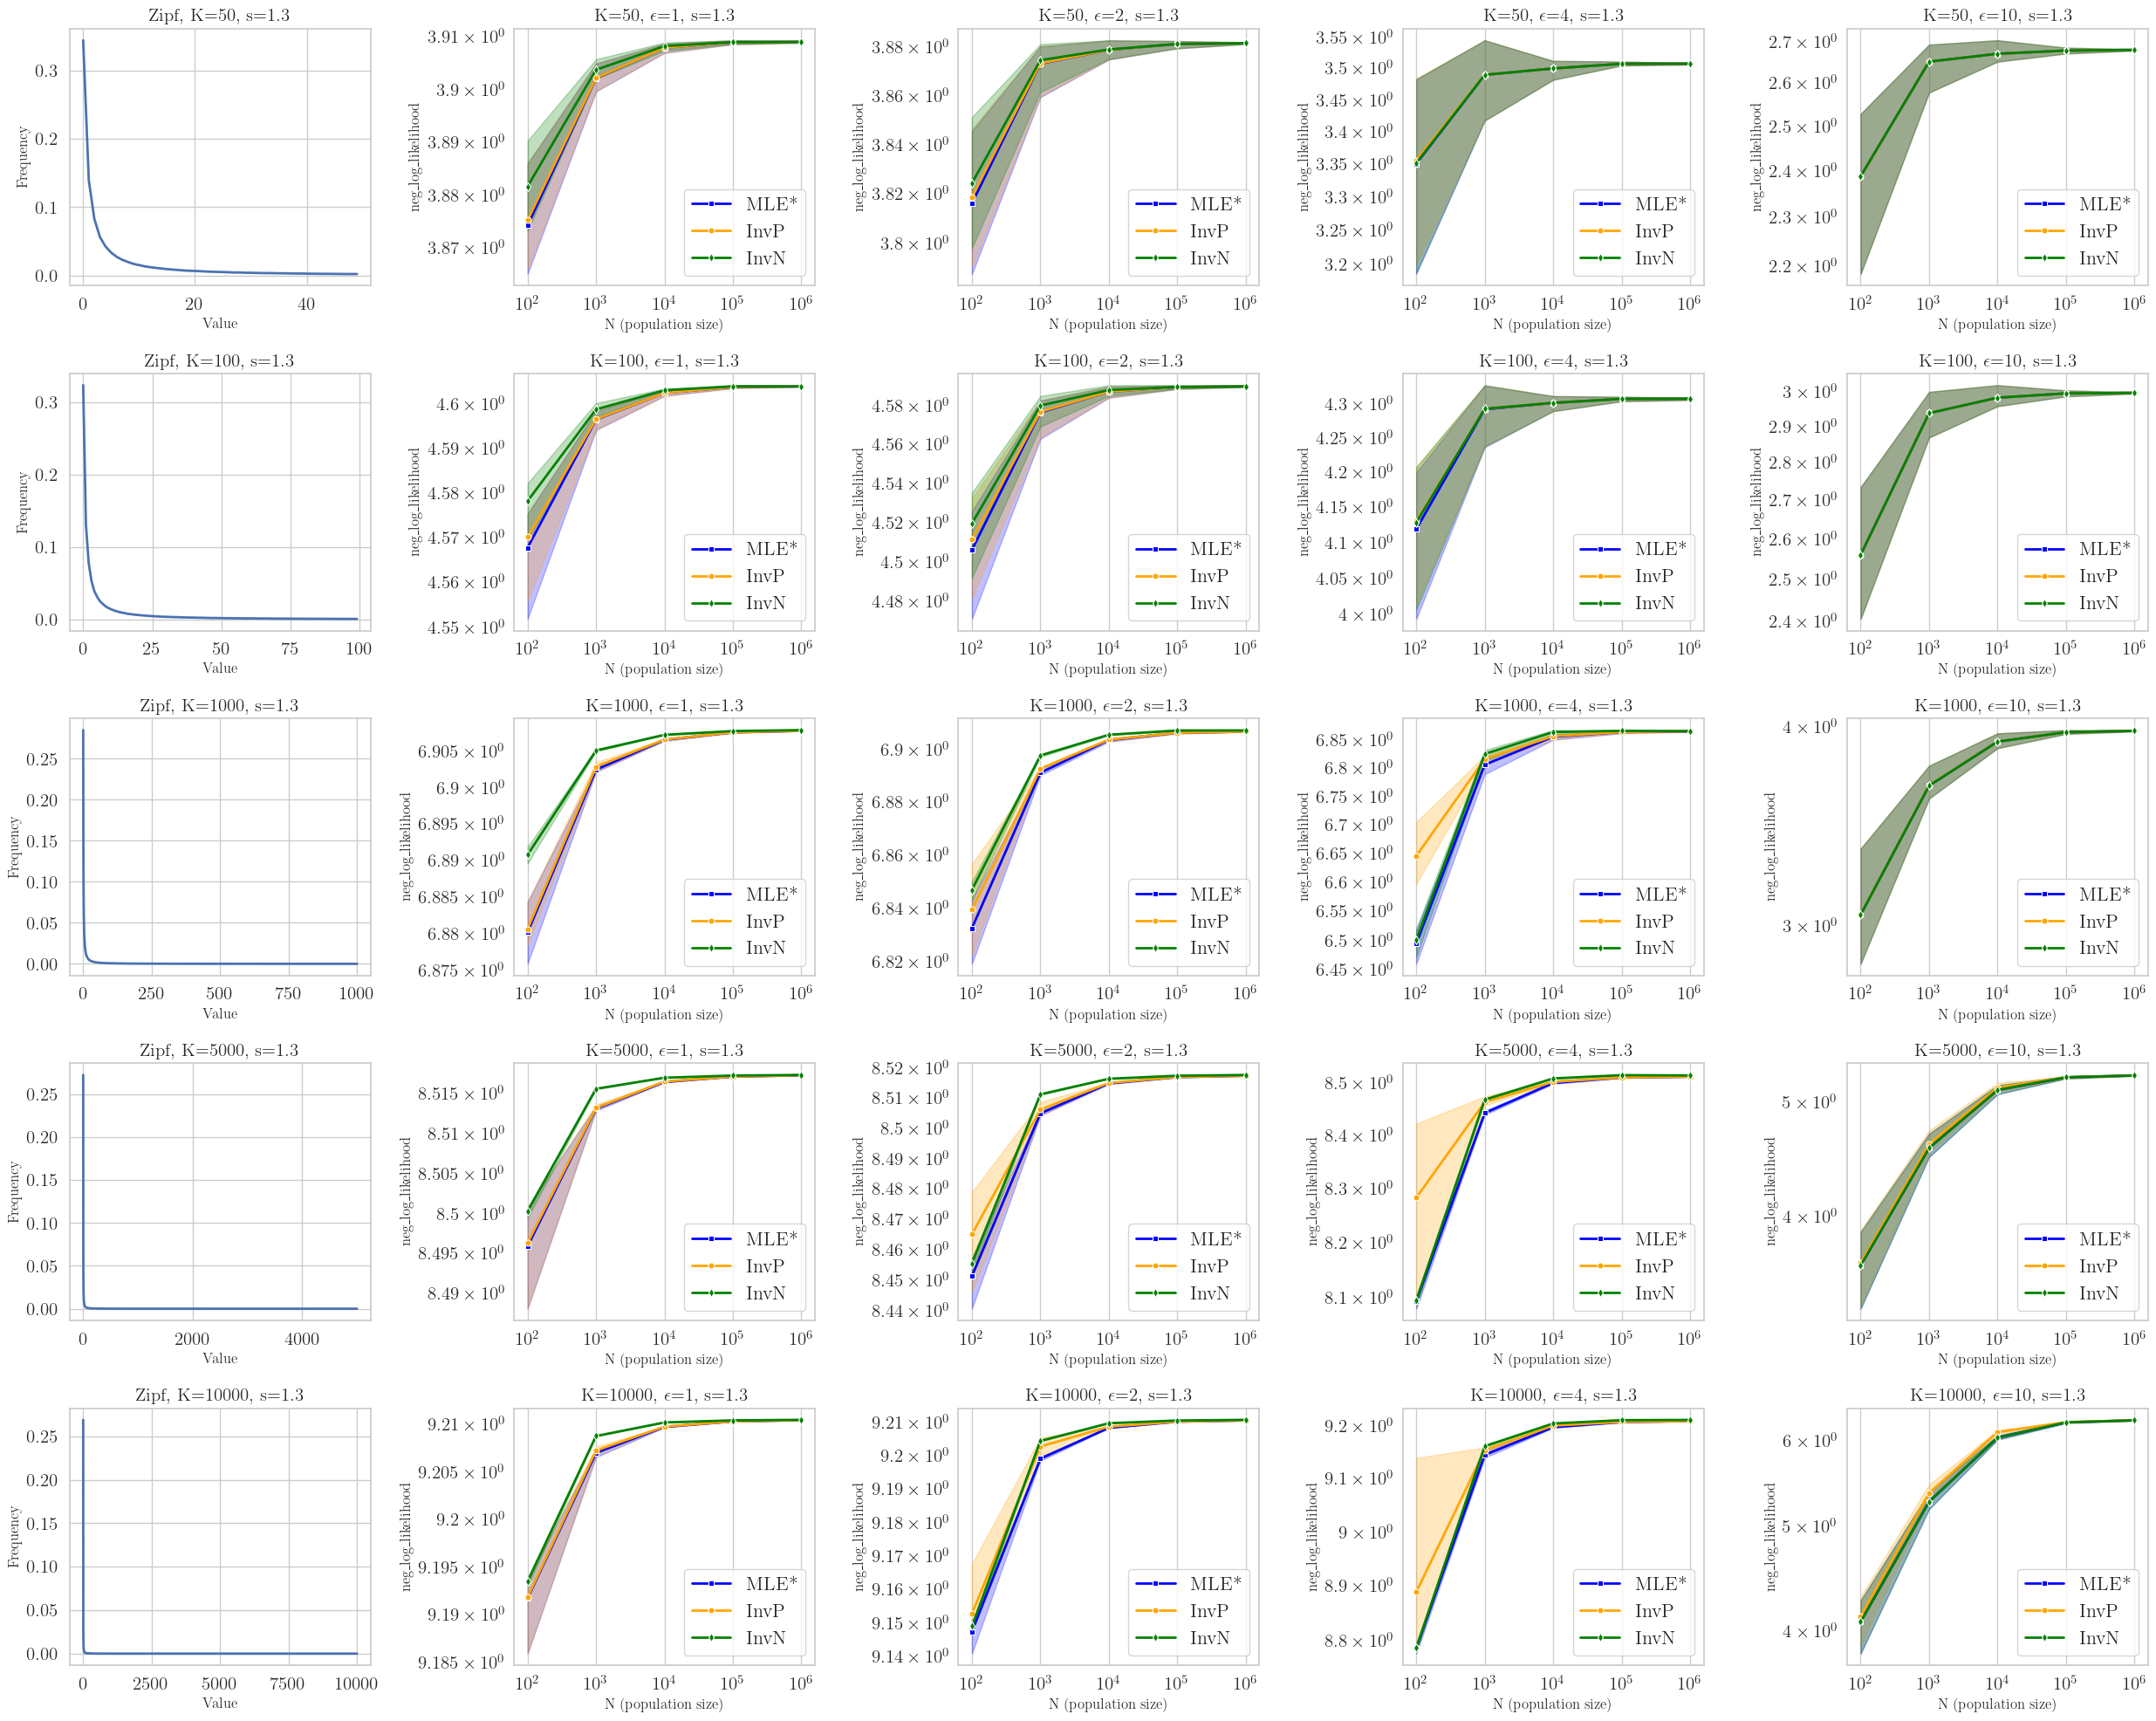

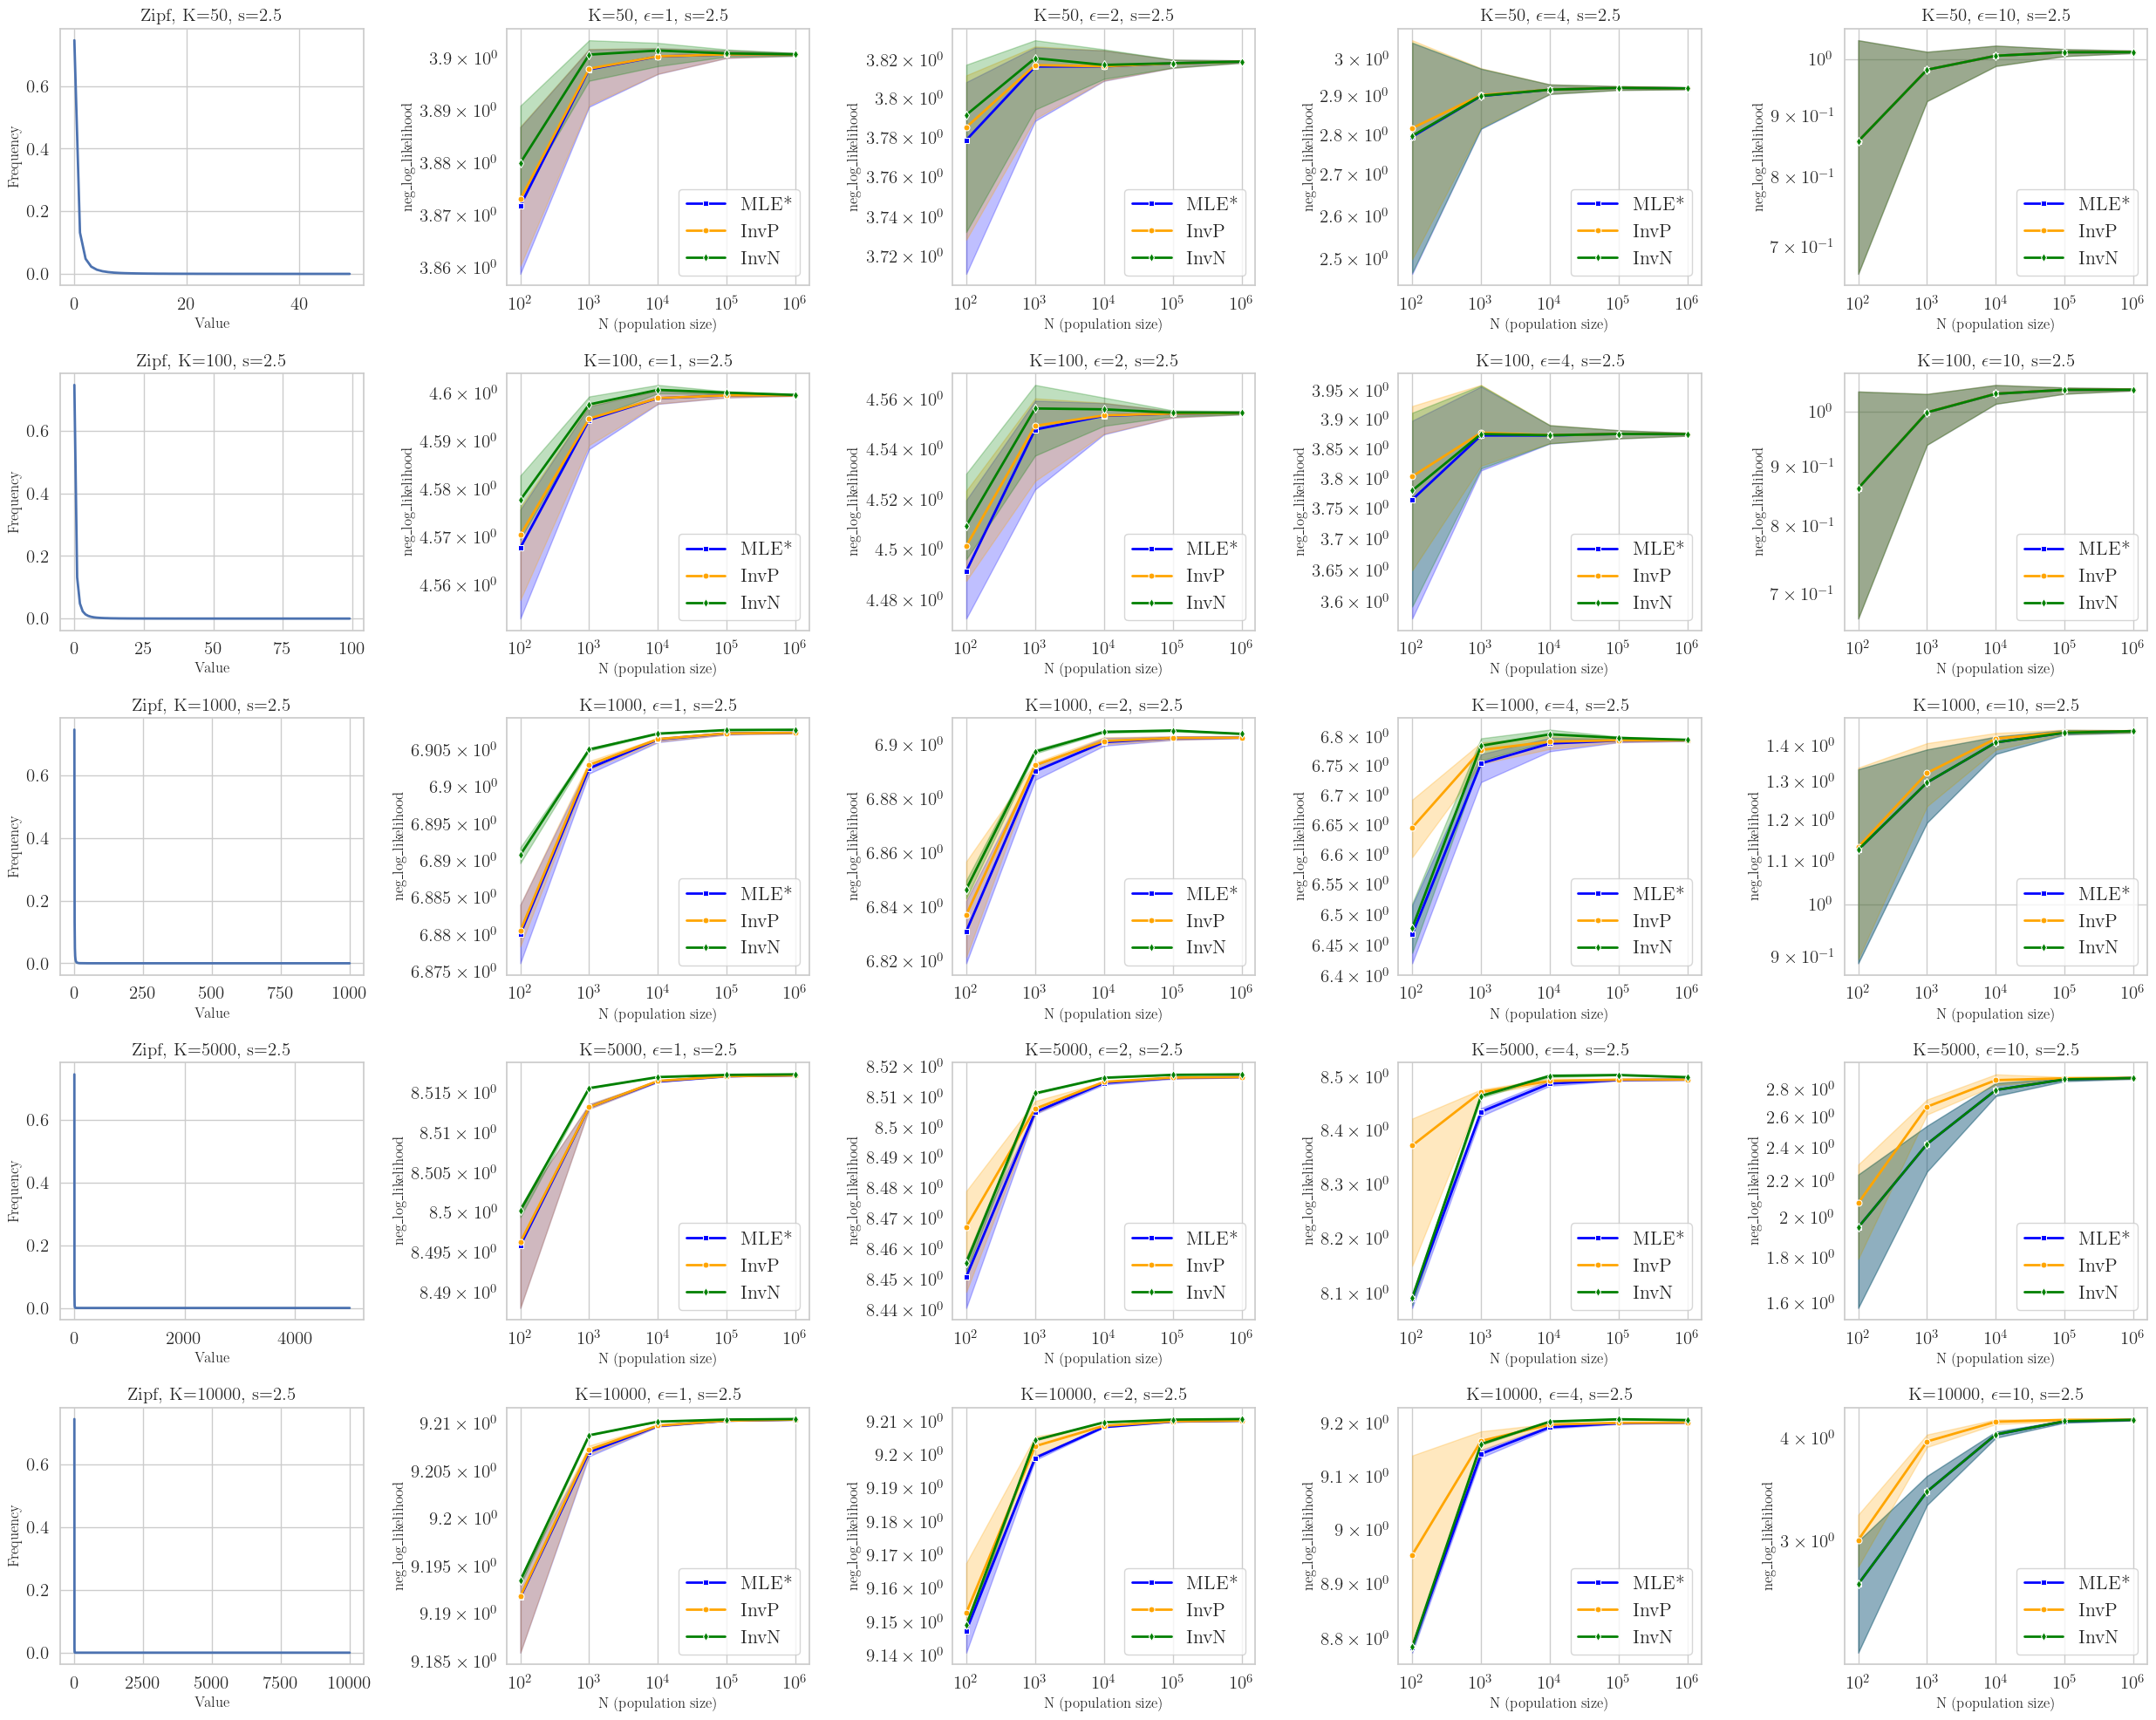


Metric: MSE


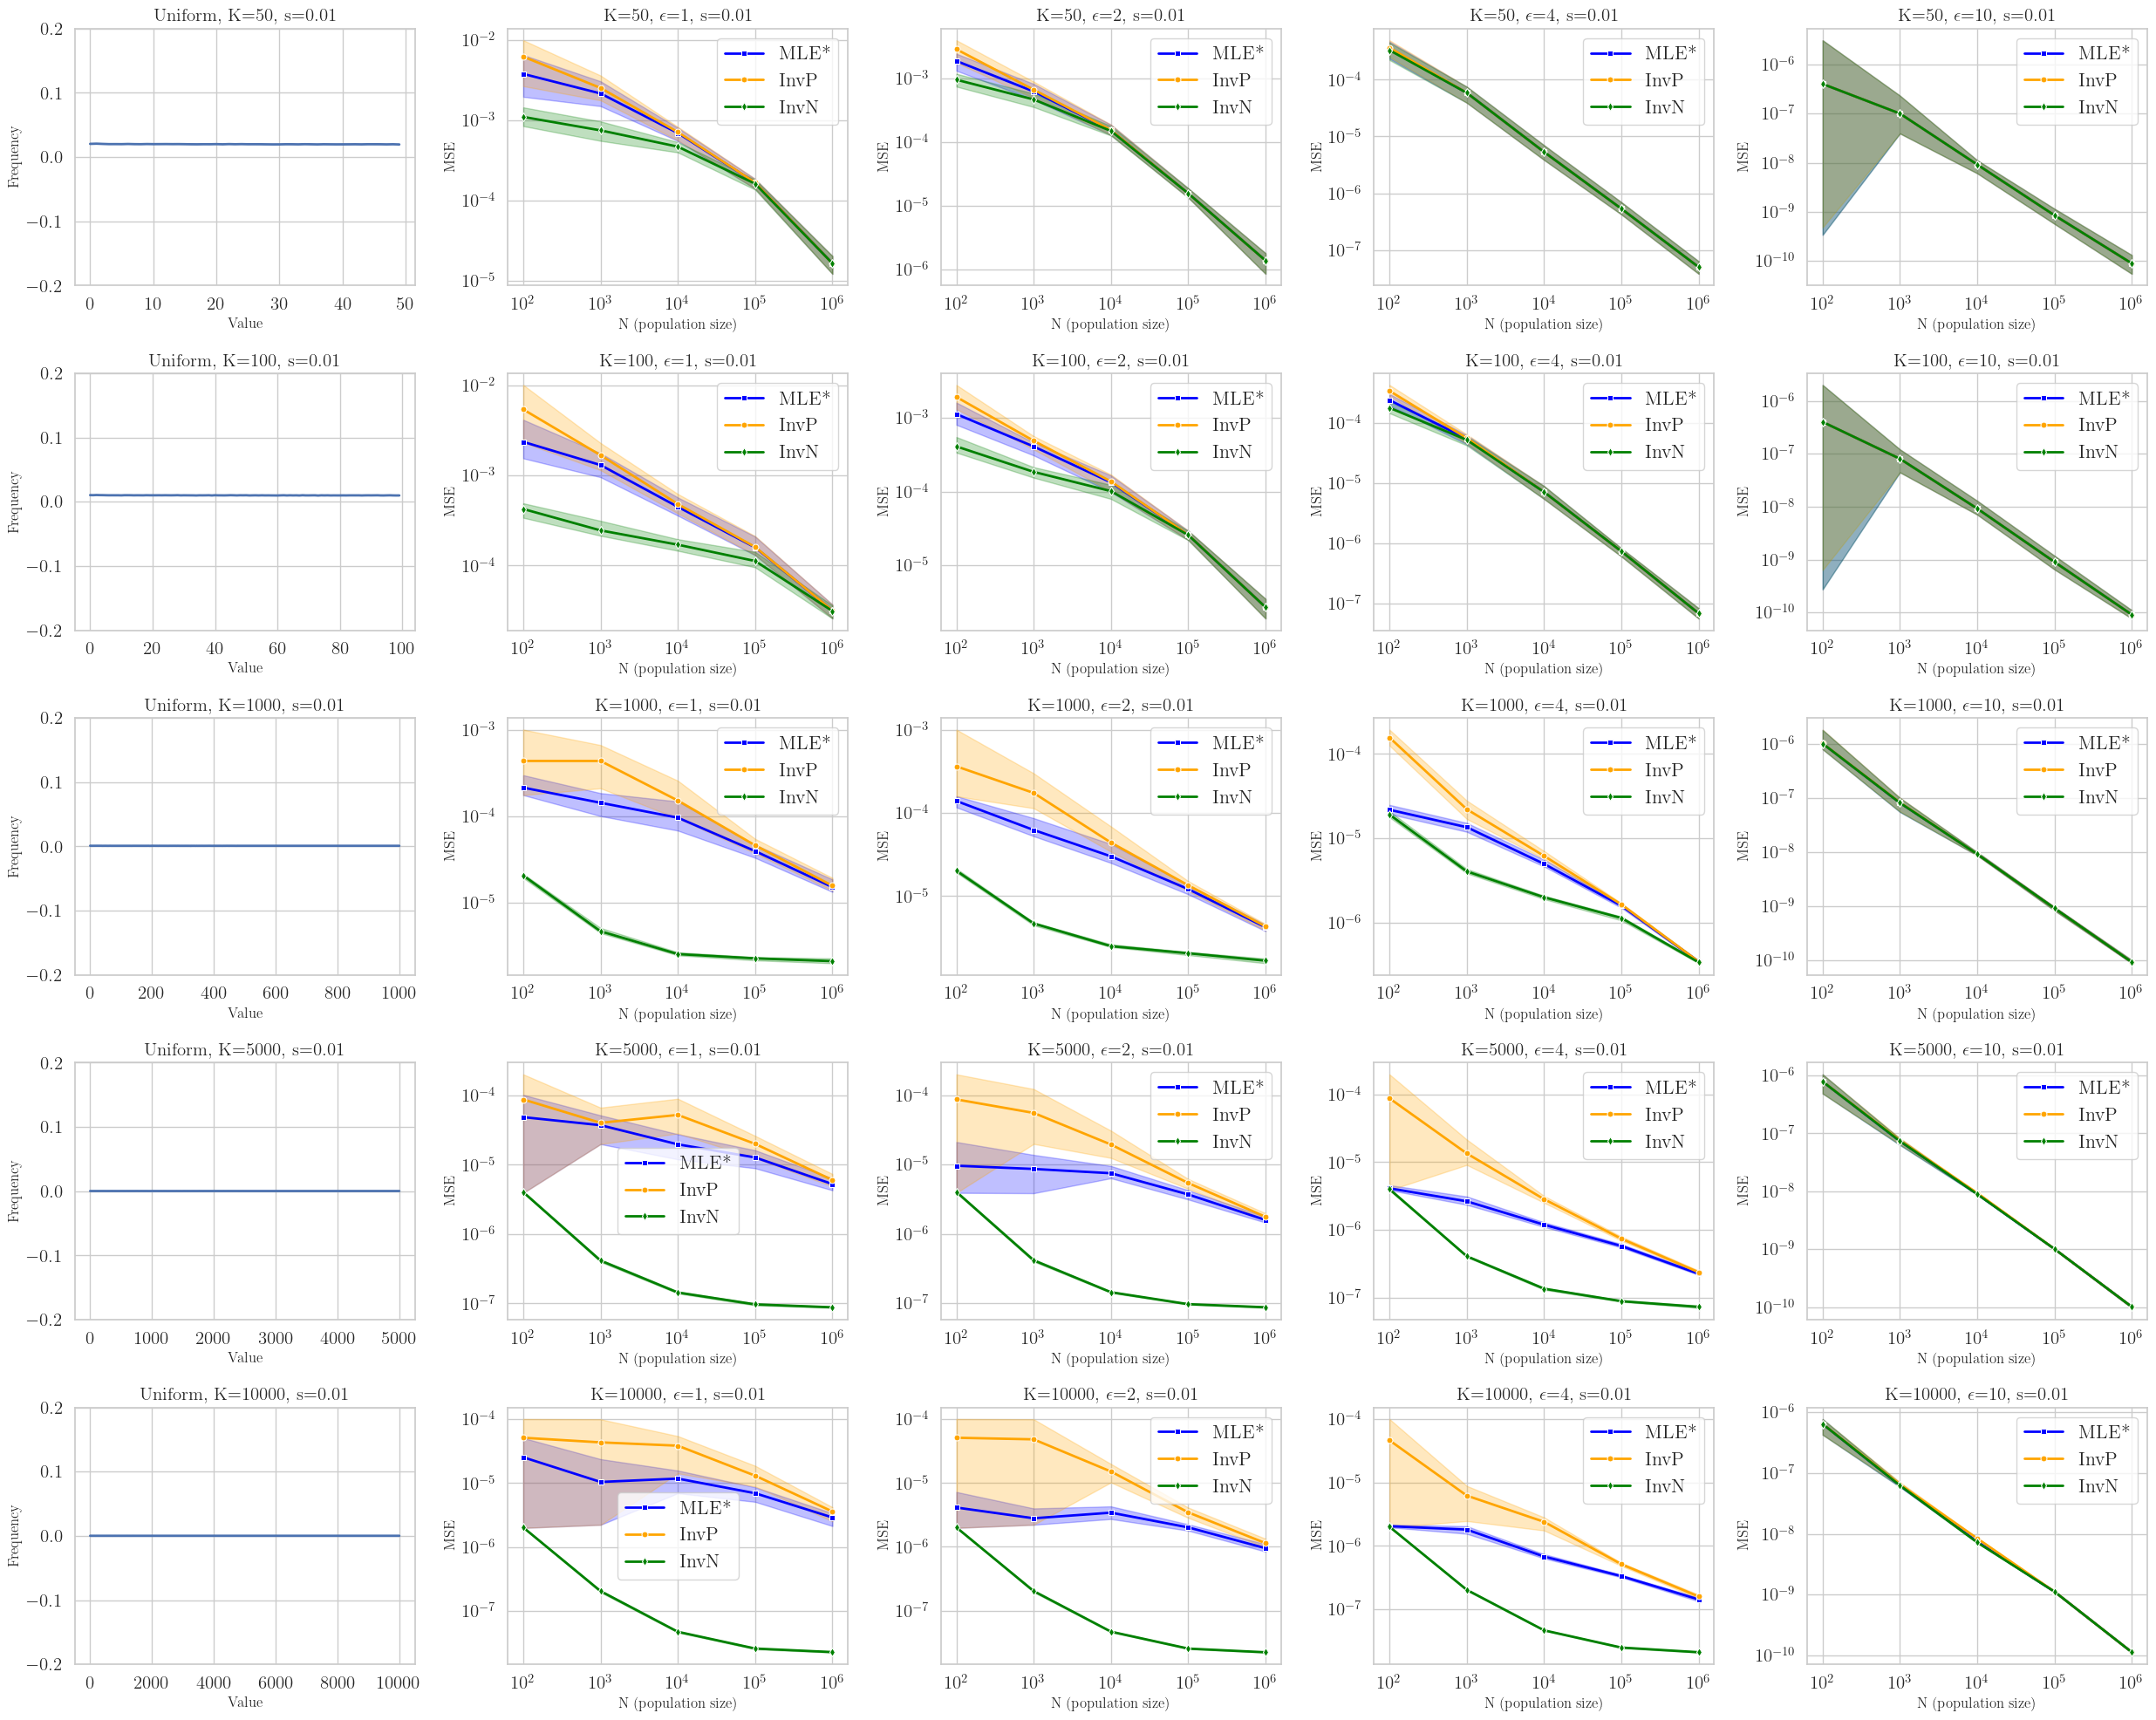

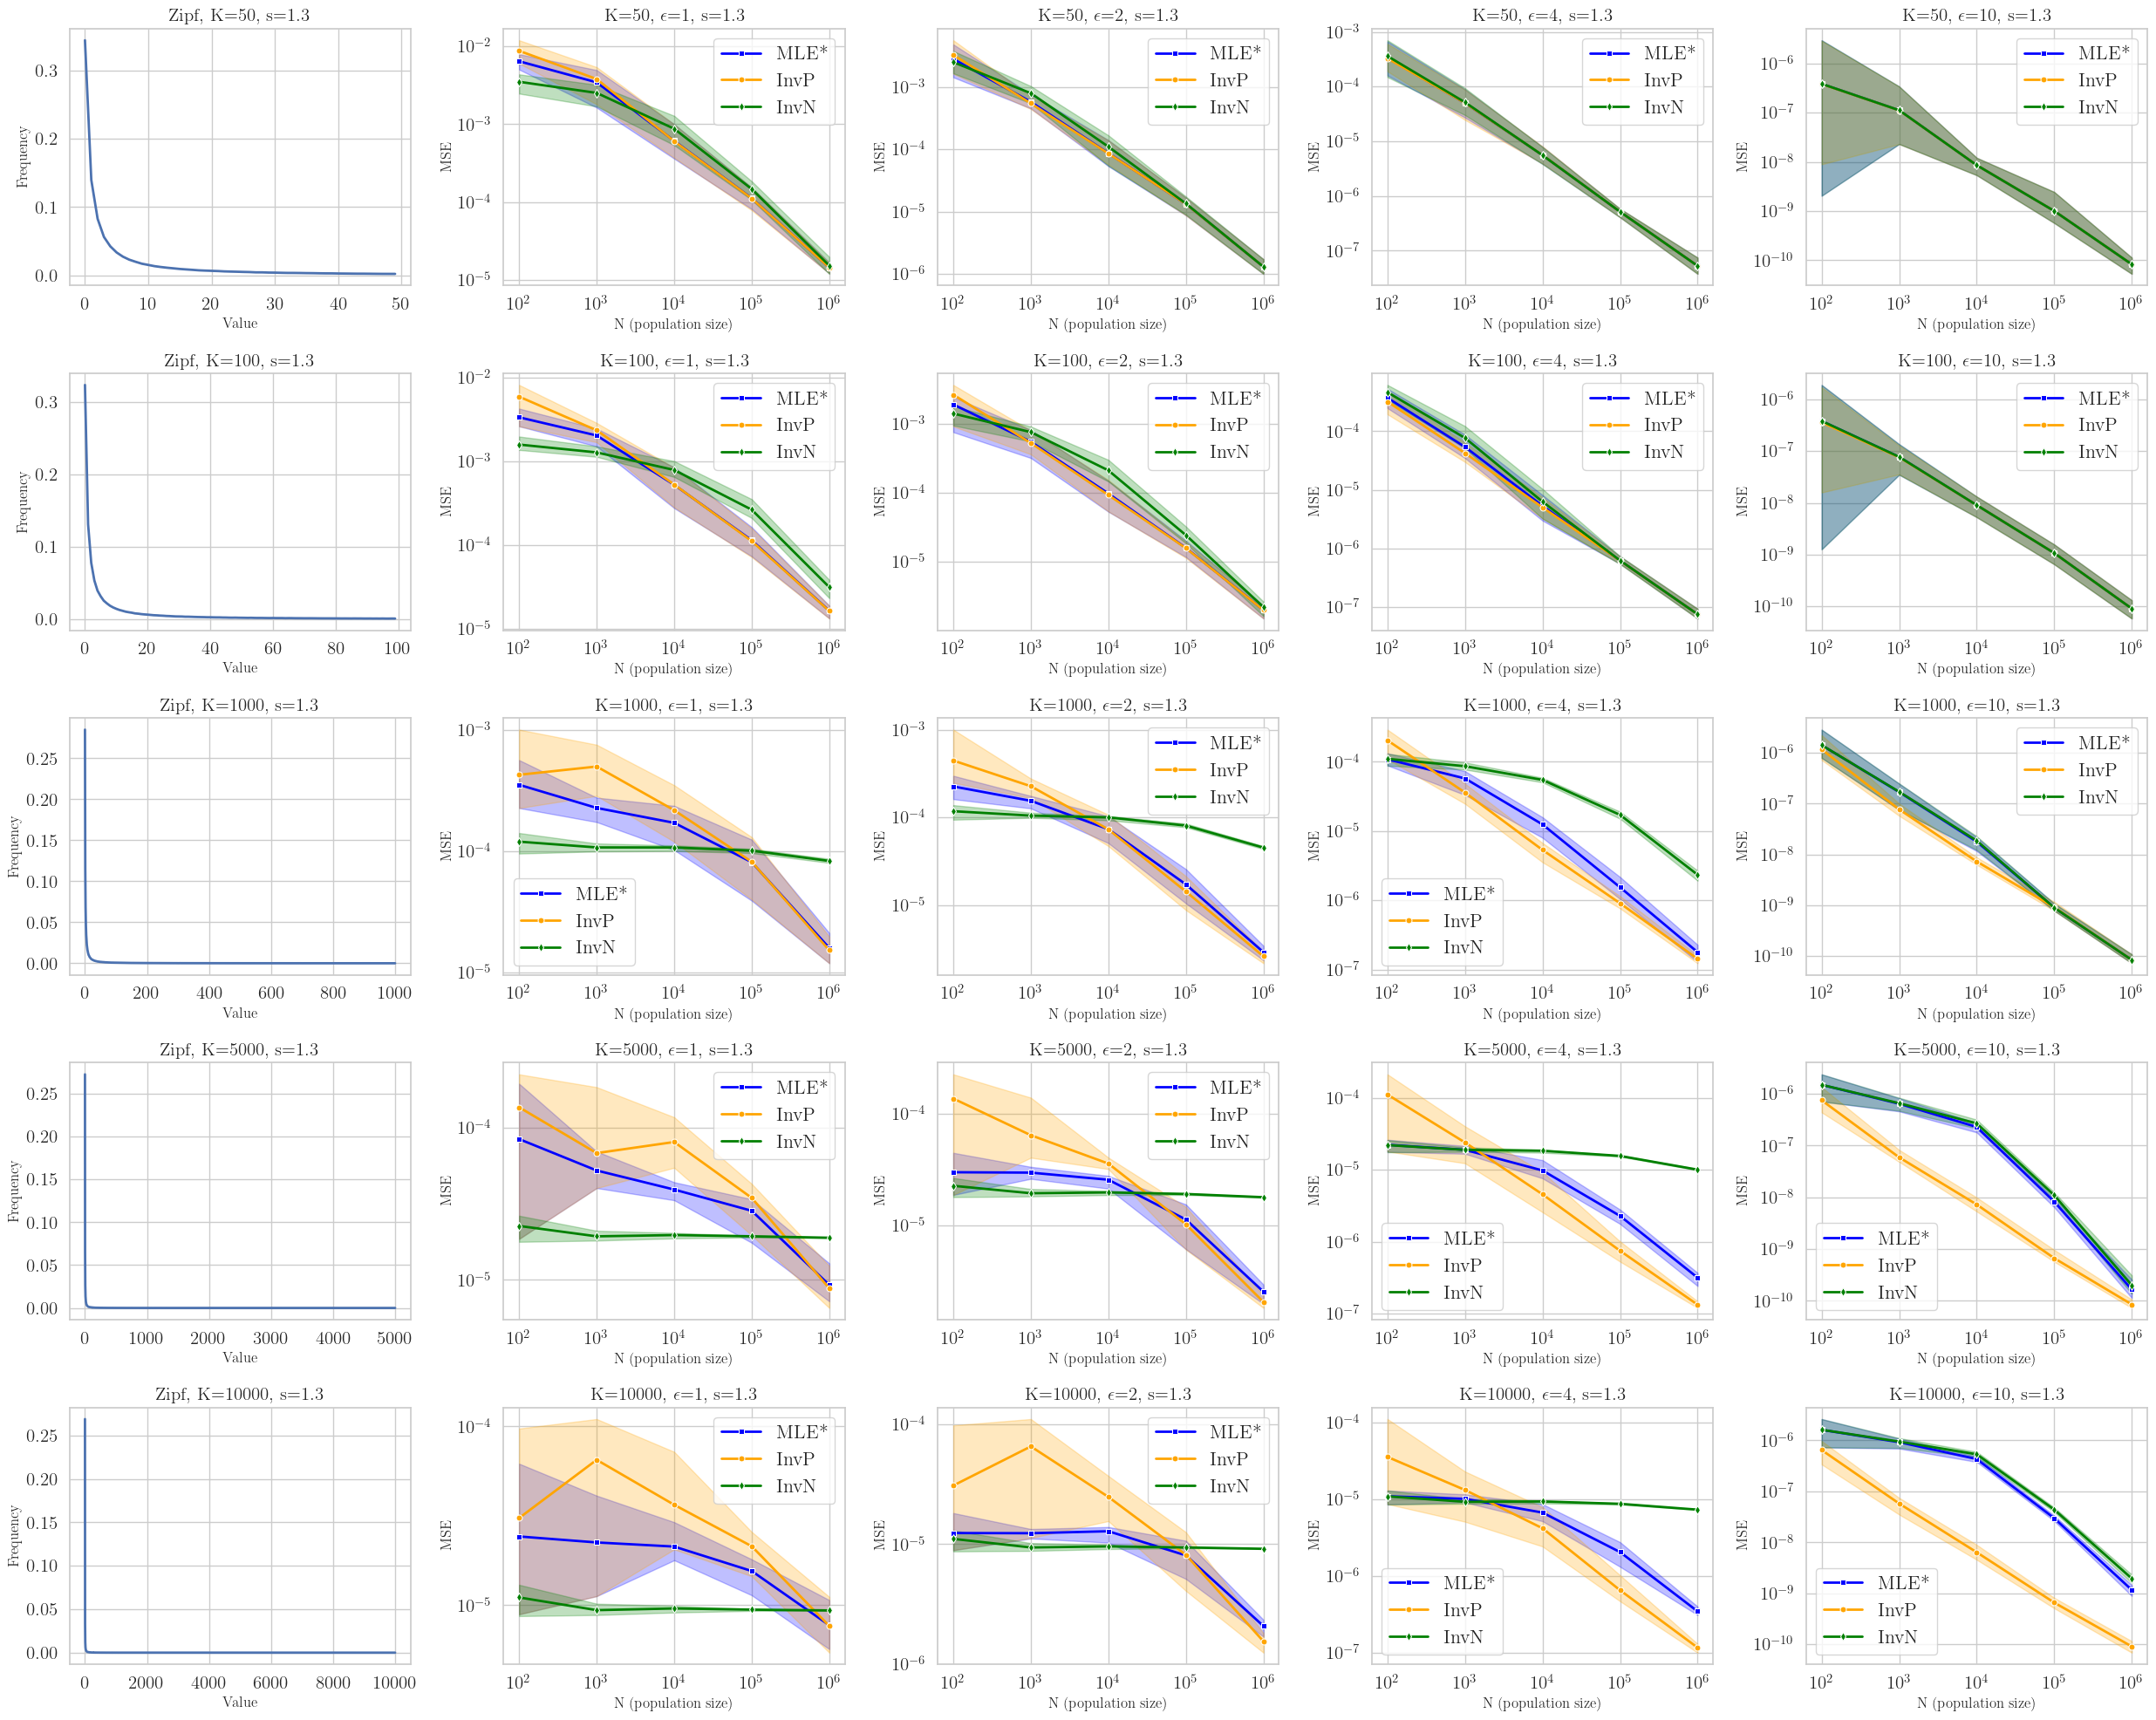

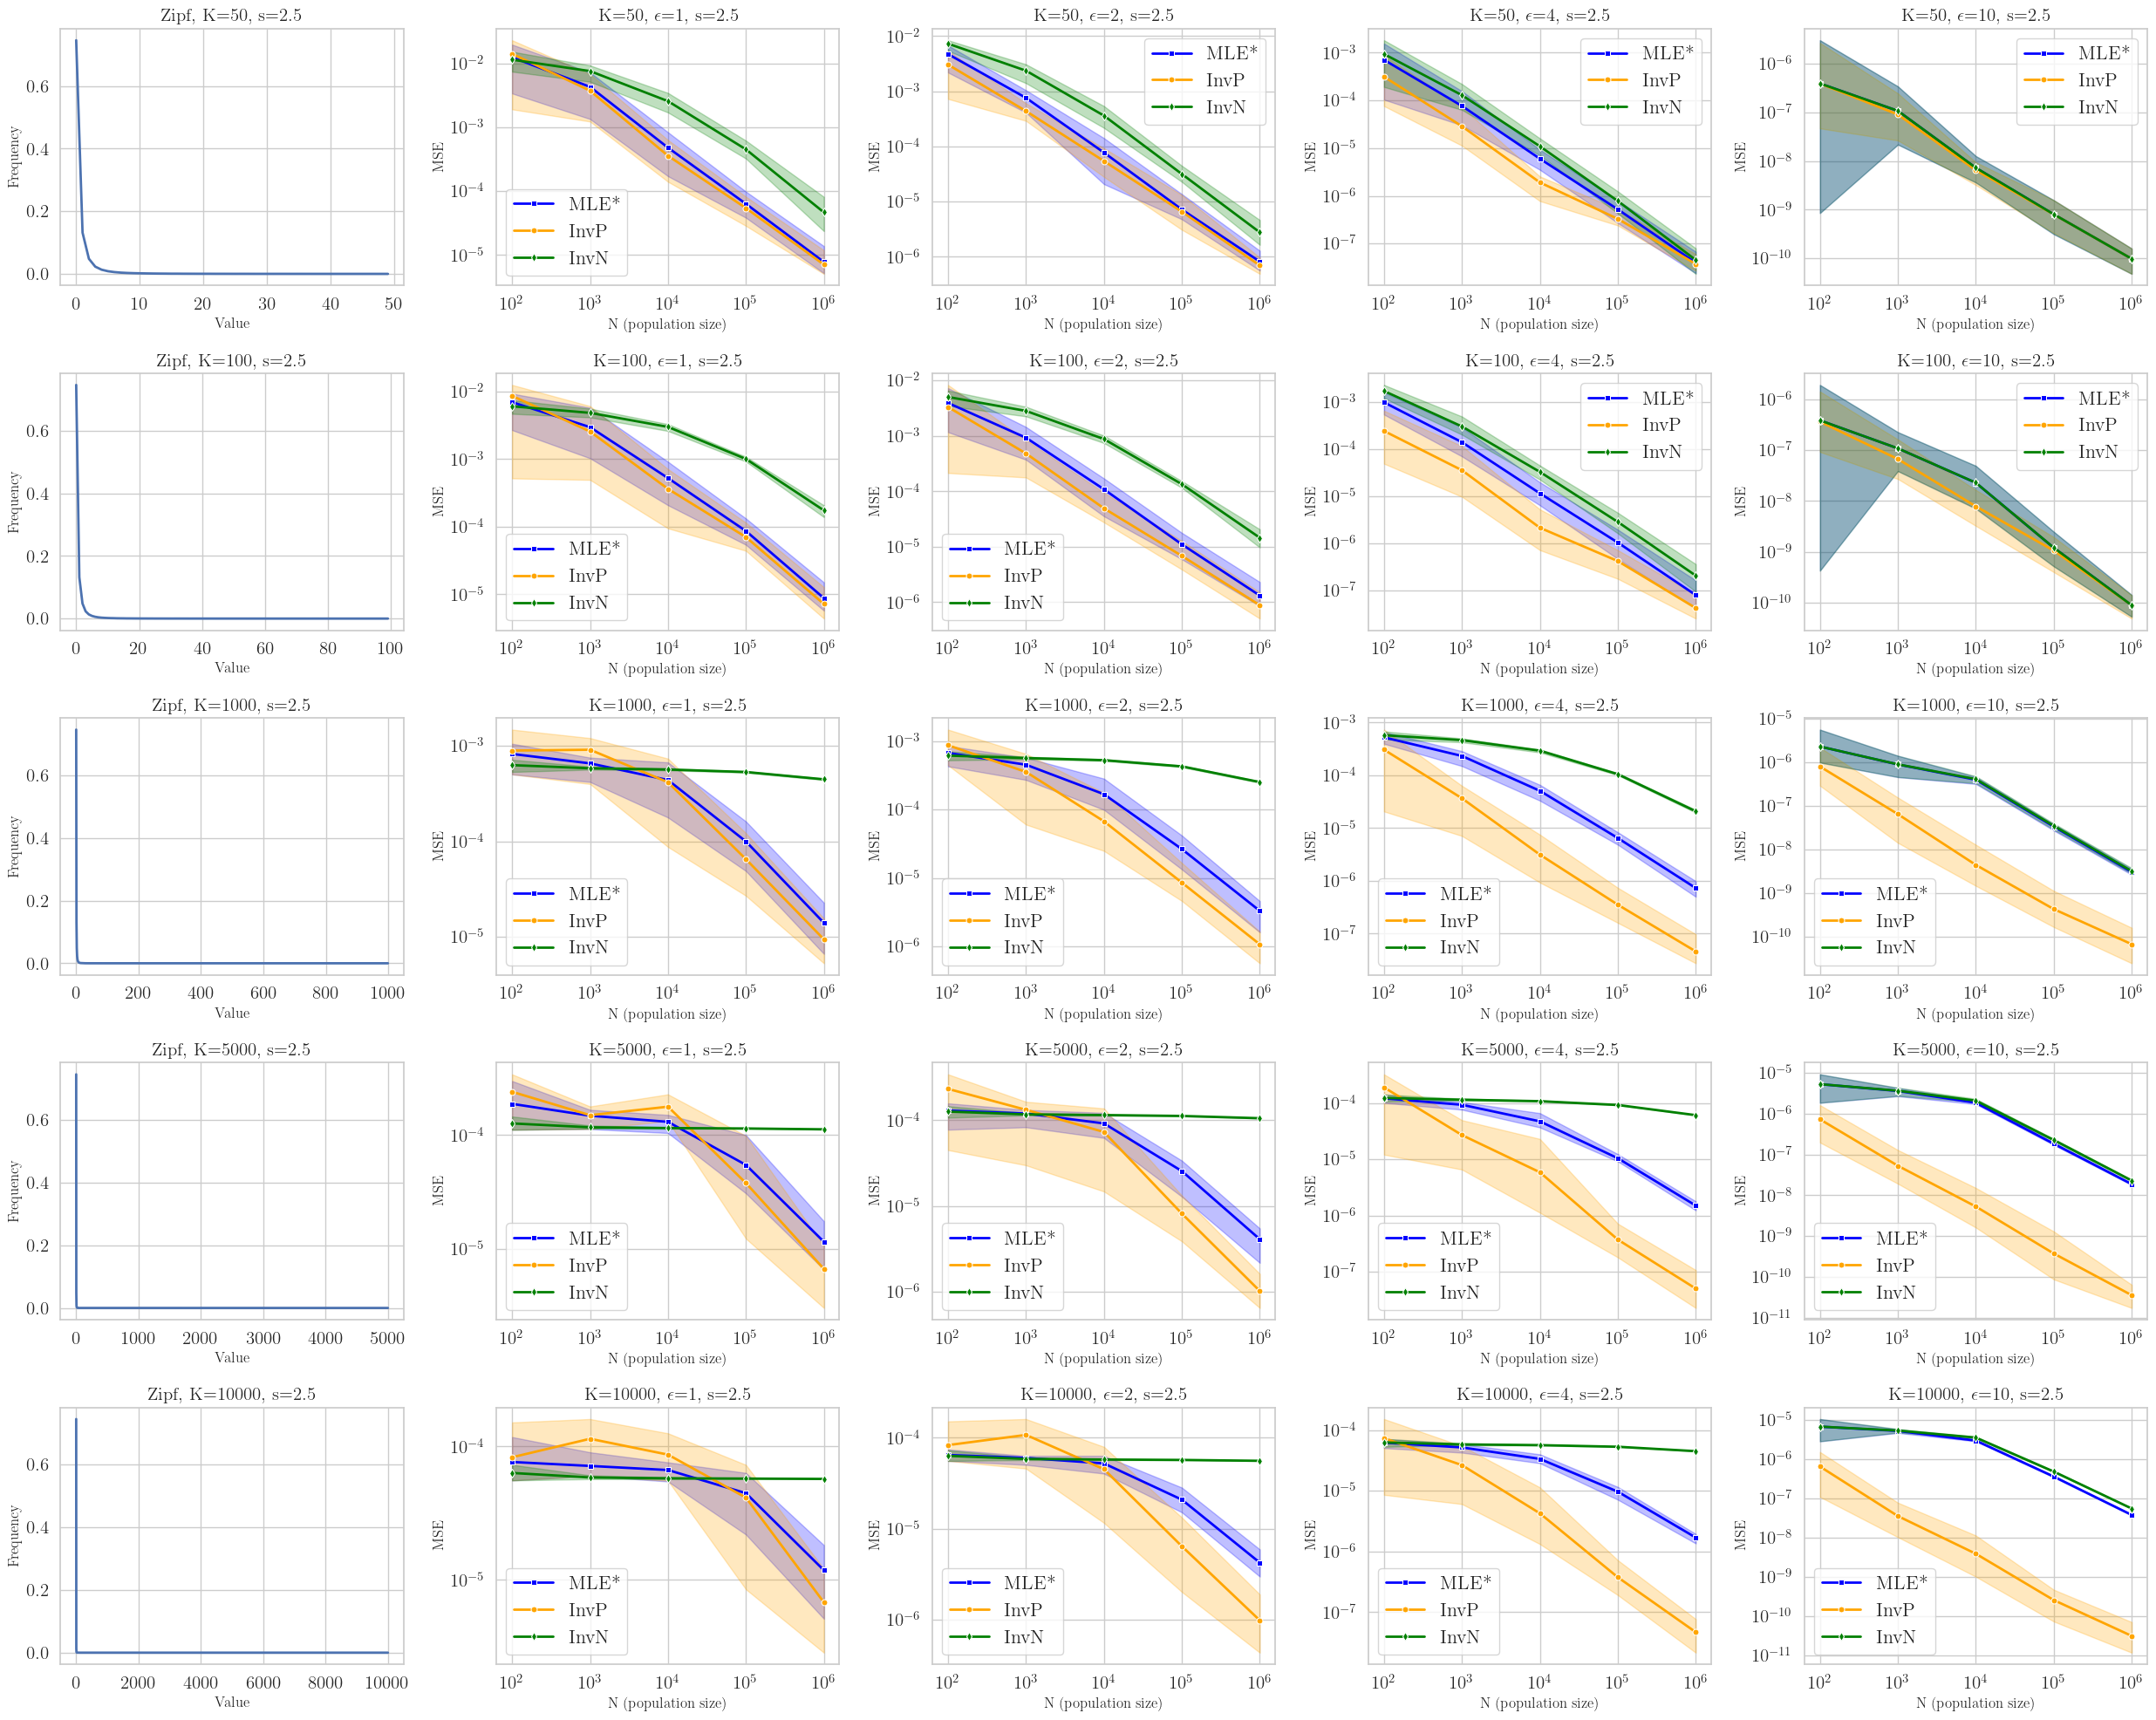

In [7]:
# get results into a DataFrame
df_all = pd.DataFrame(out)

# Define the filtered epsilon values
filtered_eps = [1, 2, 4, 10]

for met in metrics.keys():
    print(f"Metric: {met}")
    for s in pop_s:
        fig_rows = pop_K
        fig_columns = [np.nan] + filtered_eps  # only keep desired epsilons

        fig, axes = plt.subplots(
            len(fig_rows),
            len(fig_columns),
            figsize=(5 * len(fig_columns), 4 * len(fig_rows)),
            squeeze=False,
        )

        for row_idx, K in enumerate(fig_rows):
            for col_idx, eps in enumerate(fig_columns):
                ax = axes[row_idx][col_idx]
                plt.sca(ax)

                if eps is np.nan:
                    x_vals = np.arange(K)
                    ax.plot(x_vals, dic_true_hist[s][K], label=f"s={s}")
                    ax.set_title(f"Zipf, K={K}, s={s}")
                    ax.set_ylabel("Frequency")
                    ax.set_xlabel("Value")
                    if s <= 0.25:
                        ax.set_ylim(-0.2, 0.2)
                        ax.set_title(f"~Uniform, K={K}, s={s}")
                    if s >= 5:
                        ax.set_title(f"Spike, K={K}, s={s}")
                    continue

                df = df_all.query(
                    "metric == @met and eps == @eps and K == @K and s == @s"
                )
                if df.empty:
                    ax.set_title(f"No data: $\\epsilon$={eps}, K={K}, s={s}")
                    continue

                for alg in df.algorithm.unique():
                    c = color_map.get(alg)
                    mkr = marker_map.get(alg)

                    df_line = df.query("algorithm == @alg").copy()
                    sns.lineplot(
                        data=df_line,
                        x="N",
                        y="value",
                        color=c,
                        estimator="mean",
                        errorbar=("pi", 95),
                        err_kws={"alpha": 0.25},
                        marker=mkr,
                        label=alg,
                        lw=2,
                    )

                ax.set_title(f"K={K}, $\\epsilon$={eps}, s={s}")
                ax.set_yscale("log")
                ax.set_xscale("log")
                ax.set_ylabel(met)
                ax.set_xlabel("N (population size)")

        plt.tight_layout()
        plt.grid(True)
        plt.savefig(f"results/zipf_dataset_s_{s}_{met}.pdf", dpi=500, bbox_inches='tight')
        plt.show()

    print("==========================================\n")


## Real-World Data Analysis

### Preprocessing and saving datasets to csv (uncomment code and run once)

In [ ]:
# import folktables
# from folktables import ACSDataSource
# import pandas as pd

# data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
# acs_data = data_source.get_data()
# Our_ACSIncome = folktables.BasicProblem(
#                                         features=[
#                                                 # 'AGEP',
#                                                 # 'COW',
#                                                 # 'SCHL',
#                                                 # 'MAR',
#                                                 'OCCP',
#                                                 # 'POBP',
#                                                 # 'RELP',
#                                                 # 'WKHP',
#                                                 # 'SEX',
#                                                 # 'RAC1P',
#                                                 ],
#                                         target='PINCP',
#                                         target_transform=lambda x: x,    
#                                         preprocess=folktables.adult_filter,
#                                         )
# features, target, _ = Our_ACSIncome.df_to_pandas(acs_data)
# data = pd.concat([features, target.astype(int)], axis=1)
# data.to_csv("data/ACSIncome.csv", index=False)
# data = pd.read_csv("data/ACSIncome.csv")

# s = pd.read_csv(
#     "data/kosarak.dat.txt",
#     sep=r"\s+",          # any whitespace
#     header=None,
#     usecols=[0],         # first field only
#     engine="python"      # needed for regex sep
# ).squeeze("columns")     # -> Series instead of 1-col DF
# s.to_csv("data/kosarak.csv", index=False)

### Running experiments (real-world datasets)

In [24]:
# Read data
dataset = 'ACSIncome'  # 'kosarak' or 'ACSIncome'
data = pd.read_csv("data/"+dataset+".csv")
pop_N = [len(data)] 
pop_eps = range(1, 11)  # Epsilon values to vary

if dataset == "ACSIncome":    
    pop_s = ['PUMA']
    pop_K = [70201]

    # pop_s = ['PINCP']
    # pop_K = [1423000]
else:
    pop_s = ['0']
    pop_K = [41270]


# Each combination is (eps, N, K, s)
pops = list(product(pop_eps, pop_N, pop_K, pop_s))
combinations = list(product(range(len(pops)), range(n_repeats), algorithms, metrics))
dic_true_hist = {s:{K:None for K in pop_K} for s in pop_s}

# Run in parallel
num_cores = multiprocessing.cpu_count()
results = Parallel(n_jobs=num_cores)(
    delayed(run_experiment)(data, i, j, alg, met)
    for i, j, alg, met in tqdm(combinations)
)

# Unpack results
out = []
dic_true_hist = {s: {K: None for K in pop_K} for s in pop_s}

for res, (s, K, true_hist) in results:
    out.append(res)
    dic_true_hist[s][K] = true_hist   # Overwrite or store the final version

100%|██████████| 600/600 [00:21<00:00, 27.59it/s]


### Plotting

Metric: MSE


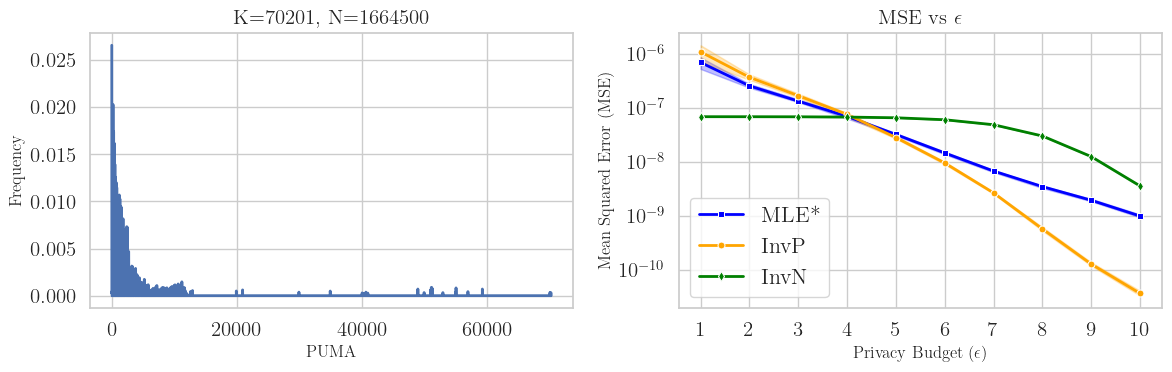

In [25]:
df_all = pd.DataFrame(out)

for met in ['MSE']:# neg_log_likelihood
    print(f"Metric: {met}")
    for s in pop_s:
        for K in pop_K:
            true_hist = dic_true_hist[s][K]

            if true_hist is None:
                print(f"No histogram for K={K}, s={s}")
                continue

            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            # === Left: Histogram of true distribution ===
            ax = axes[0]
            x_vals = np.arange(len(true_hist))
            ax.plot(x_vals, true_hist)
            ax.set_ylabel("Frequency")
            ax.set_xlabel(s if dataset == "ACSIncome" else "URL index")
            ax.set_title(f"K={K}, N={pop_N[0]}")
            ax.set_yscale("linear")
            ax.set_xscale("linear")

            # === Right: ε vs MSE ===
            ax = axes[1]
            df = df_all.query(
                "metric == @met and K == @K and s == @s"
            )
            if df.empty:
                ax.set_title(f"No data for K={K}, s={s}")
                continue

            for alg in df.algorithm.unique():
                c = color_map.get(alg)
                mkr = marker_map.get(alg)
                df_alg = df.query("algorithm == @alg").copy()
                sns.lineplot(
                    data=df_alg,
                    x="eps",
                    y="value",
                    label=alg,
                    color=c,
                    estimator="mean",
                    errorbar=("pi", 95),
                    err_kws={"alpha": 0.25},
                    marker=mkr,
                    lw=2,
                    ax=ax
                )

            ax.set_title("MSE vs $\epsilon$")
            ax.set_xlabel("Privacy Budget ($\epsilon$)")
            ax.set_ylabel("Mean Squared Error (MSE)")
            ax.set_yscale("log")
            ax.set_xticks(pop_eps)
            ax.set_xticklabels(pop_eps)
            ax.grid(True)
            ax.legend()

            # === Save and show ===
            plt.tight_layout()
            fname = f"results/real_dataset_{dataset}_K{K}_s{s}_{met}.pdf" if dataset == 'kosarak' else f"results/real_dataset_{dataset}_K{K}_s{s}_{met}.pdf"
            plt.savefig(fname, dpi=500, bbox_inches='tight')
            plt.show()